## Purpose: Define the time-aware cart-to-purchase prediction task and its evaluation strategy.

# 03 — Cart-to-Purchase Prediction Model

This notebook trains and evaluates machine-learning models to predict whether a user-item cart candidate will result in a purchase within the following 14 days.

**Modeling principles:**
- Use only behavior available at or before the cart event time
- Split training and test data chronologically
- Compare an interpretable baseline with nonlinear machine-learning models
- Evaluate classification performance using Precision, Recall, Specificity, F1-score, ROC-AUC, and PR-AUC
- Retain the best-performing model for later explainability analysis and intervention design

In [1]:
# Purpose: Import required libraries and configure settings for time-aware classification modeling.

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 120

RANDOM_STATE = 42

In [3]:
# Purpose: Locate the project root automatically and load the feature-engineered modeling dataset.

current_path = Path.cwd().resolve()

project_root = next(
    (
        candidate
        for candidate in [current_path, *current_path.parents]
        if (candidate / "data").exists()
    ),
    current_path
)

processed_data_dir = project_root / "data" / "processed"
figures_dir = project_root / "outputs" / "figures"
tables_dir = project_root / "outputs" / "tables"
models_dir = project_root / "outputs" / "models"

models_dir.mkdir(parents=True, exist_ok=True)

modeling_data_path = (
    processed_data_dir / "cart_purchase_modeling_dataset.csv"
)

print(f"Project root: {project_root}")
print(f"Modeling file exists: {modeling_data_path.exists()}")

modeling_dataset = pd.read_csv(
    modeling_data_path,
    parse_dates=["cart_time"]
)

print(f"\nModeling dataset shape: {modeling_dataset.shape}")
print(
    "Purchase rate:",
    f"{modeling_dataset['purchased_within_14_days'].mean() * 100:.2f}%"
)

display(modeling_dataset.head())

Project root: F:\ecommerce-recommender-xai
Modeling file exists: True

Modeling dataset shape: (56385, 27)
Purchase rate: 30.70%


,visitorid,itemid,cart_time,has_prior_pair_interaction,missing_prior_pair_timing,log_prior_pair_event_count,log_prior_pair_view_count,log_prior_pair_transaction_count,log_user_event_count_before_cart,log_user_view_count_before_cart,log_user_addtocart_count_before_cart,log_user_transaction_count_before_cart,log_item_event_count_before_cart,log_item_view_count_before_cart,log_item_addtocart_count_before_cart,log_item_transaction_count_before_cart,user_prior_purchase_share,user_prior_cart_share,item_prior_purchase_share,item_prior_cart_share,prior_pair_view_share,prior_pair_recency_minutes,prior_pair_interaction_span_minutes,cart_hour,cart_dayofweek,cart_month,purchased_within_14_days
0,693516,297662,2015-05-03 03:00:04.384,0,1,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,3,6,5,0
1,979664,338222,2015-05-03 03:01:25.008,0,1,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,3,6,5,0
2,260113,125751,2015-05-03 03:04:00.603,1,0,0.6931,0.6931,0.0000,1.0986,1.0986,0.0000,0.0000,0.6931,0.6931,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,2.8769,2.8769,3,6,5,0
3,319455,342530,2015-05-03 03:10:02.006,0,1,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,3,6,5,0
4,345781,438400,2015-05-03 03:11:33.415,1,0,0.6931,0.6931,0.0000,0.6931,0.6931,0.0000,0.0000,0.6931,0.6931,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,2.0885,2.0885,3,6,5,1


In [4]:
# Purpose: Split cart candidates chronologically so the model is evaluated on later unseen behavior.

target_column = "purchased_within_14_days"

non_feature_columns = [
    "visitorid",
    "itemid",
    "cart_time",
    target_column
]

model_feature_columns = [
    column
    for column in modeling_dataset.columns
    if column not in non_feature_columns
]

split_time = modeling_dataset["cart_time"].quantile(0.80)

train_df = modeling_dataset[
    modeling_dataset["cart_time"] < split_time
].copy()

test_df = modeling_dataset[
    modeling_dataset["cart_time"] >= split_time
].copy()

X_train = train_df[model_feature_columns]
y_train = train_df[target_column]

X_test = test_df[model_feature_columns]
y_test = test_df[target_column]

print(f"Time split point: {split_time}")
print(f"\nTraining set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"\nTraining purchase rate: {y_train.mean() * 100:.2f}%")
print(f"Test purchase rate: {y_test.mean() * 100:.2f}%")
print(f"\nNumber of model features: {len(model_feature_columns)}")

Time split point: 2015-08-07 21:00:48.460400128

Training set shape: (45108, 23)
Test set shape: (11277, 23)

Training purchase rate: 31.06%
Test purchase rate: 29.27%

Number of model features: 23


In [5]:
# Purpose: Define a reusable evaluation function for binary cart-to-purchase classifiers.

def evaluate_classifier(model_name, y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall_sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "specificity": tn / (tn + fp),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "true_negative": tn,
        "false_positive": fp,
        "false_negative": fn,
        "true_positive": tp
    }

In [6]:
# Purpose: Evaluate a majority-class baseline that predicts no purchase for every cart candidate.

from sklearn.dummy import DummyClassifier

baseline_model = DummyClassifier(
    strategy="most_frequent",
    random_state=RANDOM_STATE
)

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)
baseline_prob = baseline_model.predict_proba(X_test)[:, 1]

baseline_results = evaluate_classifier(
    "Majority Class Baseline",
    y_test,
    baseline_pred,
    baseline_prob
)

baseline_results

{'model': 'Majority Class Baseline',
 'accuracy': 0.7072803050456682,
 'precision': 0.0,
 'recall_sensitivity': 0.0,
 'specificity': np.float64(1.0),
 'f1_score': 0.0,
 'roc_auc': 0.5,
 'pr_auc': 0.2927196949543318,
 'true_negative': np.int64(7976),
 'false_positive': np.int64(0),
 'false_negative': np.int64(3301),
 'true_positive': np.int64(0)}

In [7]:
# Purpose: Train an interpretable logistic-regression model with median imputation and feature scaling.

logistic_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE
        )
    )
])

logistic_pipeline.fit(X_train, y_train)

logistic_pred = logistic_pipeline.predict(X_test)
logistic_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

logistic_results = evaluate_classifier(
    "Logistic Regression",
    y_test,
    logistic_pred,
    logistic_prob
)

logistic_results

{'model': 'Logistic Regression',
 'accuracy': 0.768023410481511,
 'precision': 0.7393431167016072,
 'recall_sensitivity': 0.3205089366858528,
 'specificity': np.float64(0.953234704112337),
 'f1_score': 0.44716821639898563,
 'roc_auc': 0.7524630465161009,
 'pr_auc': 0.5947111068339893,
 'true_negative': np.int64(7603),
 'false_positive': np.int64(373),
 'false_negative': np.int64(2243),
 'true_positive': np.int64(1058)}

In [8]:
# Purpose: Train and evaluate a nonlinear Random Forest model for cart-to-purchase prediction.

random_forest_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    (
        "model",
        RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=5,
            max_features="sqrt",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    )
])

random_forest_pipeline.fit(X_train, y_train)

random_forest_pred = random_forest_pipeline.predict(X_test)
random_forest_prob = random_forest_pipeline.predict_proba(X_test)[:, 1]

random_forest_results = evaluate_classifier(
    "Random Forest",
    y_test,
    random_forest_pred,
    random_forest_prob
)

random_forest_results

{'model': 'Random Forest',
 'accuracy': 0.7638556353640152,
 'precision': 0.6952264381884945,
 'recall_sensitivity': 0.34413813995758863,
 'specificity': np.float64(0.9375626880641926),
 'f1_score': 0.4603850050658561,
 'roc_auc': 0.7504083744720984,
 'pr_auc': 0.5839481588141126,
 'true_negative': np.int64(7478),
 'false_positive': np.int64(498),
 'false_negative': np.int64(2165),
 'true_positive': np.int64(1136)}

In [9]:
# Purpose: Create chronological development and validation sets for model tuning without touching the final test set.

validation_split_time = train_df["cart_time"].quantile(0.80)

development_df = train_df[
    train_df["cart_time"] < validation_split_time
].copy()

validation_df = train_df[
    train_df["cart_time"] >= validation_split_time
].copy()

X_development = development_df[model_feature_columns]
y_development = development_df[target_column]

X_validation = validation_df[model_feature_columns]
y_validation = validation_df[target_column]

print(f"Development set shape: {X_development.shape}")
print(f"Validation set shape: {X_validation.shape}")
print(f"\nDevelopment purchase rate: {y_development.mean() * 100:.2f}%")
print(f"Validation purchase rate: {y_validation.mean() * 100:.2f}%")

Development set shape: (36086, 23)
Validation set shape: (9022, 23)

Development purchase rate: 30.92%
Validation purchase rate: 31.61%


In [10]:
# Purpose: Tune a CatBoost classifier using a chronological validation set and early stopping.

from catboost import CatBoostClassifier

catboost_tuning_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=RANDOM_STATE,
    verbose=100,
    od_type="Iter",
    od_wait=100,
    allow_writing_files=False
)

catboost_tuning_model.fit(
    X_development,
    y_development,
    eval_set=(X_validation, y_validation),
    use_best_model=True
)

best_catboost_iterations = catboost_tuning_model.get_best_iteration() + 1

print(f"Best CatBoost iteration based on validation AUC: {best_catboost_iterations}")

0:	test: 0.7174396	best: 0.7174396 (0)	total: 172ms	remaining: 2m 51s
100:	test: 0.7423281	best: 0.7423281 (100)	total: 1.53s	remaining: 13.6s
200:	test: 0.7447120	best: 0.7447120 (200)	total: 2.77s	remaining: 11s
300:	test: 0.7443979	best: 0.7451399 (230)	total: 3.95s	remaining: 9.17s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.7451398944
bestIteration = 230

Shrink model to first 231 iterations.
Best CatBoost iteration based on validation AUC: 231


In [11]:
# Purpose: Train the final CatBoost model on all training data and evaluate it once on the untouched test set.

final_catboost_model = CatBoostClassifier(
    iterations=best_catboost_iterations,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False
)

final_catboost_model.fit(X_train, y_train)

catboost_pred = final_catboost_model.predict(X_test).astype(int).ravel()
catboost_prob = final_catboost_model.predict_proba(X_test)[:, 1]

catboost_results = evaluate_classifier(
    "CatBoost",
    y_test,
    catboost_pred,
    catboost_prob
)

catboost_results

{'model': 'CatBoost',
 'accuracy': 0.7658065088232686,
 'precision': 0.7083333333333334,
 'recall_sensitivity': 0.3398970009088155,
 'specificity': np.float64(0.9420762286860582),
 'f1_score': 0.4593654042988741,
 'roc_auc': 0.7584119937820126,
 'pr_auc': 0.5947146024291362,
 'true_negative': np.int64(7514),
 'false_positive': np.int64(462),
 'false_negative': np.int64(2179),
 'true_positive': np.int64(1122)}

In [12]:
# Purpose: Select the probability threshold that maximizes F1-score on the validation set.

validation_prob = catboost_tuning_model.predict_proba(X_validation)[:, 1]

threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.01):
    validation_pred = (validation_prob >= threshold).astype(int)

    threshold_results.append({
        "threshold": round(threshold, 2),
        "precision": precision_score(
            y_validation,
            validation_pred,
            zero_division=0
        ),
        "recall_sensitivity": recall_score(
            y_validation,
            validation_pred,
            zero_division=0
        ),
        "f1_score": f1_score(
            y_validation,
            validation_pred,
            zero_division=0
        )
    })

threshold_results_df = pd.DataFrame(threshold_results)

best_threshold_row = threshold_results_df.loc[
    threshold_results_df["f1_score"].idxmax()
]

best_threshold = best_threshold_row["threshold"]

print(f"Best validation threshold: {best_threshold:.2f}")
print(f"Best validation F1-score: {best_threshold_row['f1_score']:.4f}")

display(
    threshold_results_df.sort_values(
        "f1_score",
        ascending=False
    ).head(10)
)

Best validation threshold: 0.25
Best validation F1-score: 0.5696


,threshold,precision,recall_sensitivity,f1_score
15,0.2500,0.4674,0.7290,0.5696
23,0.3300,0.5466,0.5940,0.5693
16,0.2600,0.4763,0.7072,0.5692
19,0.2900,0.5041,0.6522,0.5686
24,0.3400,0.5556,0.5813,0.5682
17,0.2700,0.4837,0.6879,0.5680
20,0.3000,0.5145,0.6336,0.5679
18,0.2800,0.4934,0.6687,0.5678
14,0.2400,0.4577,0.7461,0.5674
22,0.3200,0.5338,0.6041,0.5668


In [13]:
# Purpose: Tune an interpretable Decision Tree using chronological validation data.

from sklearn.tree import DecisionTreeClassifier

decision_tree_candidates = []

for max_depth in [3, 5, 7, 10, None]:
    for min_samples_leaf in [10, 25, 50]:
        decision_tree_model = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                DecisionTreeClassifier(
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    random_state=RANDOM_STATE
                )
            )
        ])

        decision_tree_model.fit(X_development, y_development)

        validation_prob = (
            decision_tree_model
            .predict_proba(X_validation)[:, 1]
        )
        validation_pred = (validation_prob >= 0.50).astype(int)

        decision_tree_candidates.append({
            "max_depth": max_depth,
            "min_samples_leaf": min_samples_leaf,
            "validation_f1": f1_score(
                y_validation,
                validation_pred,
                zero_division=0
            ),
            "validation_roc_auc": roc_auc_score(
                y_validation,
                validation_prob
            ),
            "validation_pr_auc": average_precision_score(
                y_validation,
                validation_prob
            )
        })

decision_tree_tuning_results = (
    pd.DataFrame(decision_tree_candidates)
    .sort_values(
        ["validation_pr_auc", "validation_roc_auc"],
        ascending=False
    )
    .reset_index(drop=True)
)

display(decision_tree_tuning_results.head(10))

best_tree_settings = decision_tree_tuning_results.iloc[0]

print("\nSelected Decision Tree settings:")
print(f"max_depth: {best_tree_settings['max_depth']}")
print(f"min_samples_leaf: {best_tree_settings['min_samples_leaf']}")

,max_depth,min_samples_leaf,validation_f1,validation_roc_auc,validation_pr_auc
0,7.0000,25,0.4325,0.7303,0.5677
1,7.0000,10,0.4287,0.7285,0.5668
2,7.0000,50,0.4366,0.7281,0.5666
3,10.0000,50,0.4532,0.7209,0.5633
4,10.0000,25,0.4813,0.7225,0.5618
5,NaN,50,0.4772,0.7087,0.5610
6,10.0000,10,0.4568,0.7183,0.5544
7,5.0000,10,0.4275,0.7263,0.5523
8,5.0000,25,0.4286,0.7261,0.5522
9,5.0000,50,0.4273,0.7246,0.5505



Selected Decision Tree settings:
max_depth: 7.0
min_samples_leaf: 25.0


In [14]:
# Purpose: Train the selected Decision Tree on all training data and evaluate it on the final temporal test set.

final_decision_tree_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    (
        "model",
        DecisionTreeClassifier(
            max_depth=int(best_tree_settings["max_depth"]),
            min_samples_leaf=int(best_tree_settings["min_samples_leaf"]),
            random_state=RANDOM_STATE
        )
    )
])

final_decision_tree_model.fit(X_train, y_train)

decision_tree_pred = final_decision_tree_model.predict(X_test)
decision_tree_prob = (
    final_decision_tree_model
    .predict_proba(X_test)[:, 1]
)

decision_tree_results = evaluate_classifier(
    "Decision Tree",
    y_test,
    decision_tree_pred,
    decision_tree_prob
)

decision_tree_results

{'model': 'Decision Tree',
 'accuracy': 0.7574709585882771,
 'precision': 0.6759950248756219,
 'recall_sensitivity': 0.3292941532868828,
 'specificity': np.float64(0.934679037111334),
 'f1_score': 0.44286005296394376,
 'roc_auc': 0.735883069535781,
 'pr_auc': 0.5616425069854563,
 'true_negative': np.int64(7455),
 'false_positive': np.int64(521),
 'false_negative': np.int64(2214),
 'true_positive': np.int64(1087)}

In [15]:
# Purpose: Tune an XGBoost classifier using chronological validation data and early stopping.

from xgboost import XGBClassifier

xgboost_tuning_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.80,
    colsample_bytree=0.80,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
    early_stopping_rounds=100
)

xgboost_tuning_model.fit(
    X_development,
    y_development,
    eval_set=[(X_validation, y_validation)],
    verbose=100
)

best_xgboost_iterations = xgboost_tuning_model.best_iteration + 1

print(
    f"Best XGBoost iteration based on validation AUC: "
    f"{best_xgboost_iterations}"
)

[0]	validation_0-auc:0.72581
[100]	validation_0-auc:0.74522
[192]	validation_0-auc:0.74434
Best XGBoost iteration based on validation AUC: 93


In [16]:
# Purpose: Train the selected XGBoost model on all training data and evaluate it on the final temporal test set.

final_xgboost_model = XGBClassifier(
    n_estimators=best_xgboost_iterations,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.80,
    colsample_bytree=0.80,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist"
)

final_xgboost_model.fit(X_train, y_train)

xgboost_pred = final_xgboost_model.predict(X_test)
xgboost_prob = final_xgboost_model.predict_proba(X_test)[:, 1]

xgboost_results = evaluate_classifier(
    "XGBoost",
    y_test,
    xgboost_pred,
    xgboost_prob
)

xgboost_results

{'model': 'XGBoost',
 'accuracy': 0.7674913540835329,
 'precision': 0.7172104926423545,
 'recall_sensitivity': 0.33959406240533174,
 'specificity': np.float64(0.9445837512537613),
 'f1_score': 0.4609375,
 'roc_auc': 0.7569571027532765,
 'pr_auc': 0.5912624100791368,
 'true_negative': np.int64(7534),
 'false_positive': np.int64(442),
 'false_negative': np.int64(2180),
 'true_positive': np.int64(1121)}

In [17]:
# Purpose: Compare and save all classification-model results on the same untouched temporal test set.

model_comparison_df = pd.DataFrame([
    baseline_results,
    logistic_results,
    random_forest_results,
    decision_tree_results,
    catboost_results,
    xgboost_results
])

metric_columns = [
    "accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
    "pr_auc"
]

model_comparison_df[metric_columns] = (
    model_comparison_df[metric_columns]
    .round(4)
)

model_comparison_df.to_csv(
    tables_dir / "06_cart_purchase_model_comparison.csv",
    index=False
)

display(model_comparison_df)

,model,accuracy,precision,recall_sensitivity,specificity,f1_score,roc_auc,pr_auc,true_negative,false_positive,false_negative,true_positive
0,Majority Class Baseline,0.7073,0.0000,0.0000,1.0000,0.0000,0.5000,0.2927,7976,0,3301,0
1,Logistic Regression,0.7680,0.7393,0.3205,0.9532,0.4472,0.7525,0.5947,7603,373,2243,1058
2,Random Forest,0.7639,0.6952,0.3441,0.9376,0.4604,0.7504,0.5839,7478,498,2165,1136
3,Decision Tree,0.7575,0.6760,0.3293,0.9347,0.4429,0.7359,0.5616,7455,521,2214,1087
4,CatBoost,0.7658,0.7083,0.3399,0.9421,0.4594,0.7584,0.5947,7514,462,2179,1122
5,XGBoost,0.7675,0.7172,0.3396,0.9446,0.4609,0.7570,0.5913,7534,442,2180,1121


In [18]:
# Purpose: Evaluate the final CatBoost model on the test set using the validation-selected F1-optimal threshold.

catboost_tuned_pred = (
    catboost_prob >= best_threshold
).astype(int)

catboost_tuned_results = evaluate_classifier(
    f"CatBoost (threshold={best_threshold:.2f})",
    y_test,
    catboost_tuned_pred,
    catboost_prob
)

catboost_tuned_results

{'model': 'CatBoost (threshold=0.25)',
 'accuracy': 0.6641837368094351,
 'precision': 0.45378470901483453,
 'recall_sensitivity': 0.7228112693123296,
 'specificity': np.float64(0.6399197592778335),
 'f1_score': 0.5575417688982358,
 'roc_auc': 0.7584119937820126,
 'pr_auc': 0.5947146024291362,
 'true_negative': np.int64(5104),
 'false_positive': np.int64(2872),
 'false_negative': np.int64(915),
 'true_positive': np.int64(2386)}

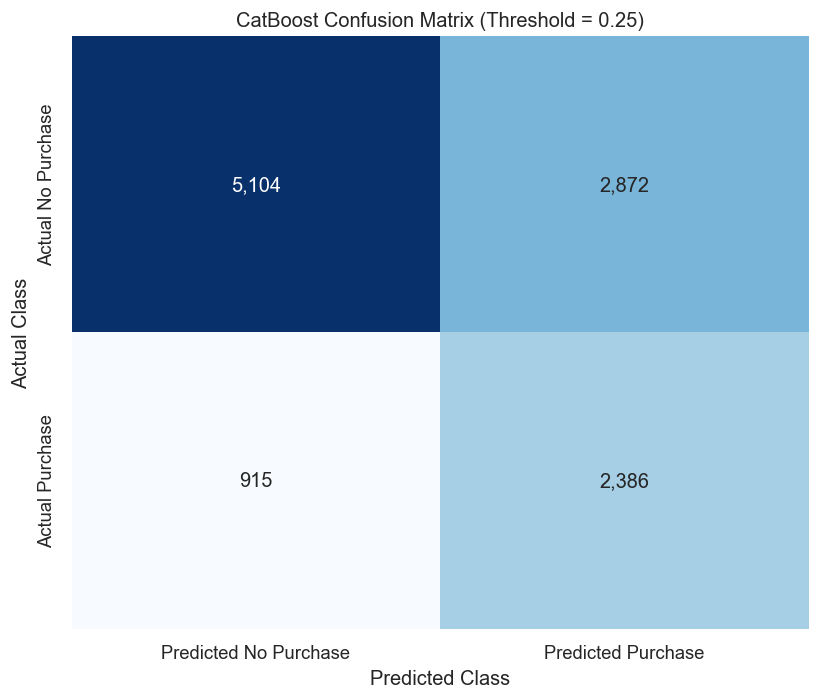

In [19]:
# Purpose: Visualize and save the confusion matrix of CatBoost at the validation-selected decision threshold.

cm = confusion_matrix(y_test, catboost_tuned_pred)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt=",",
    cmap="Blues",
    cbar=False,
    xticklabels=["Predicted No Purchase", "Predicted Purchase"],
    yticklabels=["Actual No Purchase", "Actual Purchase"]
)

plt.title(
    f"CatBoost Confusion Matrix (Threshold = {best_threshold:.2f})"
)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()

plt.savefig(
    figures_dir / "09_catboost_tuned_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
# Purpose: Add the threshold-tuned CatBoost operating point to the saved model-comparison table.

final_model_comparison_df = pd.concat(
    [
        model_comparison_df,
        pd.DataFrame([catboost_tuned_results])
    ],
    ignore_index=True
)

final_model_comparison_df[metric_columns] = (
    final_model_comparison_df[metric_columns]
    .round(4)
)

final_model_comparison_df.to_csv(
    tables_dir / "06_cart_purchase_model_comparison.csv",
    index=False
)

display(final_model_comparison_df)

,model,accuracy,precision,recall_sensitivity,specificity,f1_score,roc_auc,pr_auc,true_negative,false_positive,false_negative,true_positive
0,Majority Class Baseline,0.7073,0.0000,0.0000,1.0000,0.0000,0.5000,0.2927,7976,0,3301,0
1,Logistic Regression,0.7680,0.7393,0.3205,0.9532,0.4472,0.7525,0.5947,7603,373,2243,1058
2,Random Forest,0.7639,0.6952,0.3441,0.9376,0.4604,0.7504,0.5839,7478,498,2165,1136
3,Decision Tree,0.7575,0.6760,0.3293,0.9347,0.4429,0.7359,0.5616,7455,521,2214,1087
4,CatBoost,0.7658,0.7083,0.3399,0.9421,0.4594,0.7584,0.5947,7514,462,2179,1122
5,XGBoost,0.7675,0.7172,0.3396,0.9446,0.4609,0.7570,0.5913,7534,442,2180,1121
6,CatBoost (threshold=0.25),0.6642,0.4538,0.7228,0.6399,0.5575,0.7584,0.5947,5104,2872,915,2386


In [21]:
# Purpose: Save the final CatBoost model, its selected threshold, and feature list for later XAI analysis.

final_model_path = (
    models_dir / "final_catboost_cart_purchase_model.cbm"
)

final_catboost_model.save_model(final_model_path)

model_metadata = pd.Series({
    "model_name": "CatBoost cart-to-purchase classifier",
    "prediction_target": "Purchase of the carted item within 14 days",
    "selected_threshold": float(best_threshold),
    "test_roc_auc": float(catboost_tuned_results["roc_auc"]),
    "test_pr_auc": float(catboost_tuned_results["pr_auc"]),
    "test_f1_score": float(catboost_tuned_results["f1_score"]),
    "test_recall": float(catboost_tuned_results["recall_sensitivity"]),
    "test_precision": float(catboost_tuned_results["precision"])
})

model_metadata.to_json(
    models_dir / "final_catboost_model_metadata.json",
    indent=4
)

pd.DataFrame({
    "feature": model_feature_columns
}).to_csv(
    models_dir / "final_catboost_feature_list.csv",
    index=False
)

print(f"Saved model: {final_model_path}")
print(f"Selected threshold: {best_threshold:.2f}")

Saved model: F:\ecommerce-recommender-xai\outputs\models\final_catboost_cart_purchase_model.cbm
Selected threshold: 0.25


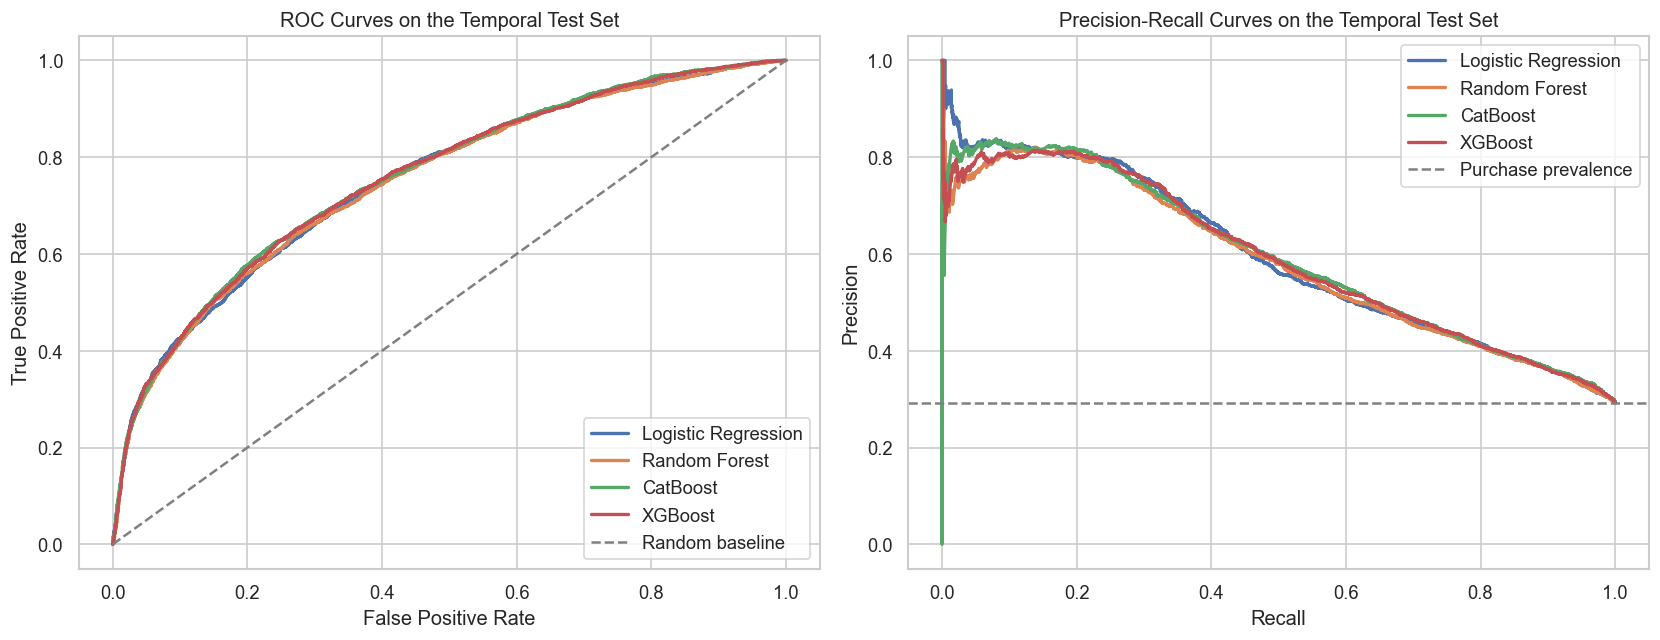

In [22]:
# Purpose: Visualize and save ROC and Precision-Recall curves for the main predictive models.

from sklearn.metrics import roc_curve, precision_recall_curve

model_probabilities = {
    "Logistic Regression": logistic_prob,
    "Random Forest": random_forest_prob,
    "CatBoost": catboost_prob,
    "XGBoost": xgboost_prob
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for model_name, probabilities in model_probabilities.items():
    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_test,
        probabilities
    )
    precision, recall, _ = precision_recall_curve(
        y_test,
        probabilities
    )

    axes[0].plot(
        false_positive_rate,
        true_positive_rate,
        linewidth=2,
        label=model_name
    )

    axes[1].plot(
        recall,
        precision,
        linewidth=2,
        label=model_name
    )

axes[0].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random baseline"
)

axes[0].set_title("ROC Curves on the Temporal Test Set")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")

axes[1].axhline(
    y=y_test.mean(),
    linestyle="--",
    color="gray",
    label="Purchase prevalence"
)

axes[1].set_title("Precision-Recall Curves on the Temporal Test Set")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(loc="upper right")

plt.tight_layout()

plt.savefig(
    figures_dir / "10_model_roc_pr_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Purpose: Summarize model-selection results and define the final operational prediction model.

### Modeling Conclusions

- Five machine-learning models were evaluated using the same chronological test set.
- CatBoost achieved the strongest ranking performance, with ROC-AUC = 0.7584 and PR-AUC = 0.5947.
- The final CatBoost decision threshold was selected on a separate validation set rather than on the test set.
- At the selected threshold of 0.25, CatBoost identified 72.28% of future purchases and achieved an F1-score of 0.5575.
- The selected model is appropriate for prioritizing low-cost interventions for cart candidates, while the predicted probability can be used to reserve high-cost incentives for the highest-probability group.
- The final model, threshold metadata, feature list, comparison table, confusion matrix, and ROC/PR figure were saved in the project outputs.